In [26]:
import sys
import os
from pathlib import Path

_project_root = Path('..').resolve()
os.environ.setdefault('DATA_CATALOG_PATH', str(_project_root / 'data' / 'catalog'))
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from cyber_trader.data.catalog import get_catalog
from cyber_trader.config import get_settings
from cyber_trader.indicators.factor_engine import (
    KeltnerBreakoutFactor, EMACrossoverFactor, StochasticFactor
)

catalog  = get_catalog()
settings = get_settings()
print(f'Catalog: {settings.data_catalog_path}')

Catalog: /Users/bytedance/github_personal/cyber_trader/data/catalog


In [36]:
# ═══════════════════════════════════════════════
#  修改这里来切换时间段 / 品种
# ═══════════════════════════════════════════════
INSTRUMENT = 'ETH-USDT-SWAP.OKX'
TIMEFRAME  = '15m'          # 15m | 1h | 4h | 1d
START      = '2026-06-03'
END        = '2026-06-06'
# ═══════════════════════════════════════════════

In [37]:
from cyber_trader.data.okx_downloader import timeframe_to_bar_type

BAR_TYPE = timeframe_to_bar_type(INSTRUMENT, TIMEFRAME)
start_ts = pd.Timestamp(START, tz='UTC')
end_ts   = pd.Timestamp(END,   tz='UTC') + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
start_ns, end_ns = int(start_ts.value), int(end_ts.value)

print(f'Instrument : {INSTRUMENT}  [{TIMEFRAME}]')
print(f'Range      : {start_ts.date()}  →  {end_ts.date()}')

# Factors — params from config/backtest_15m.yaml
kc_f    = KeltnerBreakoutFactor(period=30, k=2.0,  weight=0.5)
ema_f   = EMACrossoverFactor(fast=9,  slow=21,      weight=0.3)
stoch_f = StochasticFactor(period_k=14, period_d=3, weight=0.2)

print('Loading bars from catalog...')
all_bars = catalog.bars([BAR_TYPE])
print(f'Total in catalog: {len(all_bars):,}')

rows = []
for bar in all_bars:
    kc_f.update(bar)
    ema_f.update(bar)
    stoch_f.update(bar)
    if start_ns <= bar.ts_event <= end_ns:
        rows.append({
            'ts':          pd.Timestamp(bar.ts_event, unit='ns', tz='UTC'),
            'open':        bar.open.as_double(),
            'high':        bar.high.as_double(),
            'low':         bar.low.as_double(),
            'close':       bar.close.as_double(),
            'kc_score':    kc_f.score()    if kc_f.is_initialized    else 0.0,
            'ema_score':   ema_f.score()   if ema_f.is_initialized   else 0.0,
            'stoch_score': stoch_f.score() if stoch_f.is_initialized else 0.0,
        })

if not rows:
    raise ValueError(f'No bars found for {INSTRUMENT} [{TIMEFRAME}] in {START} ~ {END}. '
                     f'Run download_data.py first.')

df = pd.DataFrame(rows).set_index('ts')
print(f'Plotting    : {len(df):,} bars  [{df.index[0]}  →  {df.index[-1]}]')
df.head()

Instrument : ETH-USDT-SWAP.OKX  [15m]
Range      : 2026-06-03  →  2026-06-06
Loading bars from catalog...
Total in catalog: 50,078
Plotting    : 350 bars  [2026-06-03 00:00:00+00:00  →  2026-06-06 15:15:00+00:00]


,open,high,low,close,kc_score,ema_score,stoch_score
ts,,,,,,,
2026-06-03 00:00:00+00:00,1858.79,1868.64,1853.01,1867.13,-1.000000,-0.174805,-0.183011
2026-06-03 00:15:00+00:00,1867.14,1874.23,1862.03,1862.99,-1.000000,-0.168325,-0.295009
2026-06-03 00:30:00+00:00,1862.99,1871.98,1859.20,1869.25,-0.833022,-0.153207,-0.119946
2026-06-03 00:45:00+00:00,1869.25,1870.97,1866.23,1866.23,-0.890923,-0.142974,-0.196049
2026-06-03 01:00:00+00:00,1866.23,1866.84,1854.46,1857.81,-1.000000,-0.142829,-0.418951


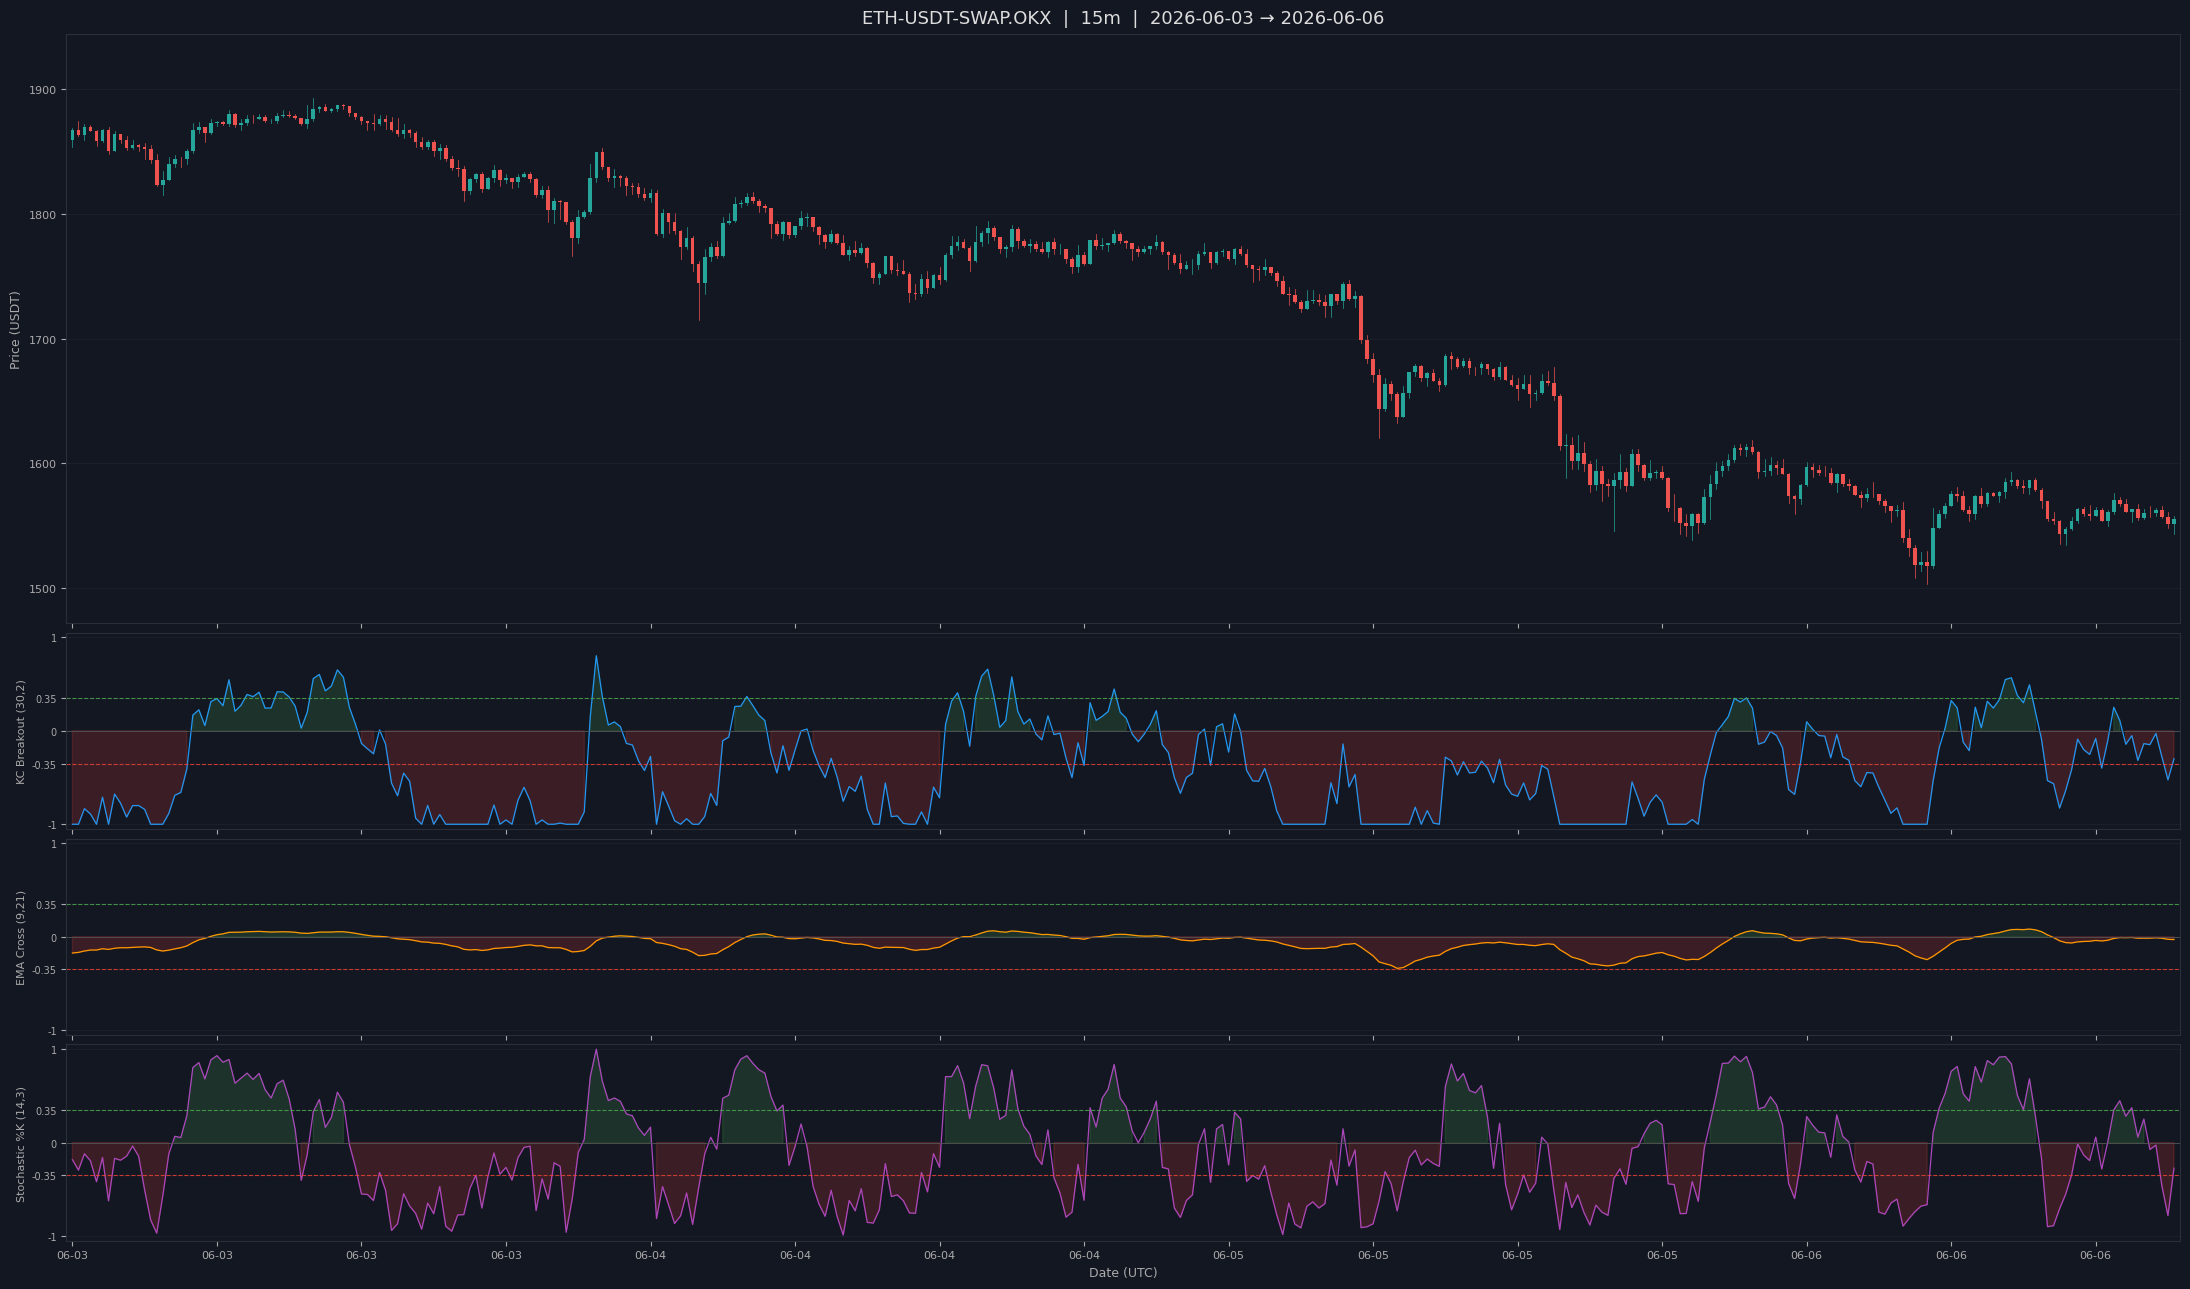

Done — 350 bars  →  eth_15m_indicators_2026-06-03_2026-06-06.png


In [38]:
n = len(df)

# X 轴刻度密度：根据总 bar 数自动选合适的间隔
# 目标：图上显示约 20-30 个刻度
bars_per_15m = 1
_tf_bars = {'15m': 1, '1h': 4, '4h': 16, '1d': 96}
bars_per_day = 96 // _tf_bars.get(TIMEFRAME, 1)

if n <= 500:
    tick_step = max(1, bars_per_day // 4)      # 6小时一格
elif n <= 2000:
    tick_step = bars_per_day                   # 1天一格
elif n <= 10000:
    tick_step = bars_per_day * 7               # 1周一格
else:
    tick_step = bars_per_day * 30              # 1月一格

tick_pos    = list(range(0, n, tick_step))
tick_fmt    = '%m-%d' if n <= 10000 else '%Y-%m'
tick_labels = [df.index[i].strftime(tick_fmt) for i in tick_pos]

fig, axes = plt.subplots(
    4, 1, figsize=(22, 13), sharex=True,
    gridspec_kw={'height_ratios': [3, 1, 1, 1]}
)
ax_c, ax_kc, ax_ema, ax_st = axes
fig.patch.set_facecolor('#131722')
for ax in axes:
    ax.set_facecolor('#131722')
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2e39')

# ── Candlestick ───────────────────────────────────────────────────────────────
width = 0.6
bull  = '#26a69a'
bear  = '#ef5350'

for i, (ts, row) in enumerate(df.iterrows()):
    color = bull if row['close'] >= row['open'] else bear
    safe_high = min(row['high'], row['close'] * 1.5)
    safe_low  = max(row['low'],  row['close'] * 0.5)
    ax_c.plot([i, i], [safe_low, safe_high], color=color, linewidth=0.5, zorder=1)
    bot = min(row['open'], row['close'])
    h   = max(abs(row['close'] - row['open']), row['close'] * 1e-4)
    ax_c.add_patch(mpatches.Rectangle(
        (i - width / 2, bot), width, h,
        facecolor=color, edgecolor='none', zorder=2
    ))

ax_c.set_xlim(-1, n)
ax_c.set_ylim(df['close'].min() * 0.97, df['close'].max() * 1.03)
ax_c.set_ylabel('Price (USDT)', color='#aaaaaa', fontsize=9)
ax_c.set_title(
    f'{INSTRUMENT}  |  {TIMEFRAME}  |  {START} → {END}',
    color='#dddddd', fontsize=13, pad=8
)
ax_c.yaxis.grid(True, color='#2a2e39', linewidth=0.5)

# ── Factor score panels ───────────────────────────────────────────────────────
x = np.arange(n)
panels = [
    (ax_kc,  'kc_score',    'KC Breakout (30,2)',   '#2196F3'),
    (ax_ema, 'ema_score',   'EMA Cross (9,21)',     '#FF9800'),
    (ax_st,  'stoch_score', 'Stochastic %K (14,3)', '#AB47BC'),
]
for ax, col, label, clr in panels:
    vals = df[col].values
    ax.plot(x, vals, color=clr, linewidth=0.9, zorder=2)
    ax.fill_between(x, vals, 0, where=(vals >= 0), alpha=0.18, color='#4CAF50', zorder=1)
    ax.fill_between(x, vals, 0, where=(vals <  0), alpha=0.18, color='#F44336', zorder=1)
    ax.axhline(0,     color='#555555', linewidth=0.6)
    ax.axhline( 0.35, color='#4CAF50', linewidth=0.8, linestyle='--', alpha=0.8)
    ax.axhline(-0.35, color='#F44336', linewidth=0.8, linestyle='--', alpha=0.8)
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel(label, color='#aaaaaa', fontsize=8)
    ax.yaxis.grid(True, color='#2a2e39', linewidth=0.5)
    ax.set_yticks([-1, -0.35, 0, 0.35, 1])
    ax.set_yticklabels(['-1', '-0.35', '0', '0.35', '1'], fontsize=7, color='#aaaaaa')

# ── X 轴（只在底部显示，上方面板隐藏） ───────────────────────────────────────
for ax in axes:
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([])
ax_st.set_xticklabels(tick_labels, color='#aaaaaa', fontsize=8)
ax_st.set_xlabel('Date (UTC)', color='#aaaaaa', fontsize=9)

plt.tight_layout(h_pad=0.3)
fname = f'eth_15m_indicators_{START}_{END}.png'.replace(':', '-')
#plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Done — {n} bars  →  {fname}')